In [24]:
# only necessary for google colab! to load models into session
!git clone https://github.com/jyjblrd/S4_Slicer
!mv S4_Slicer/* ./

fatal: destination path 'S4_Slicer' already exists and is not an empty directory.
mv: cannot move 'S4_Slicer/input_models' to './input_models': Directory not empty
mv: cannot move 'S4_Slicer/pickle_files' to './pickle_files': Directory not empty


In [25]:
!pip install tetgen
!pip install pyvista
!pip install scipy
!pip install open3d
!pip install pygcode
!apt-get install -qq xvfb libgl1-mesa-glx
!pip install pyvista -qq

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [26]:
import networkx as nx
import numpy as np
import pyvista as pv
import tetgen
from scipy.optimize import minimize, least_squares
from scipy.spatial.transform import Rotation as R
import open3d as o3d
import time
import pickle
import base64
pv.set_jupyter_backend('static') # Google colab only allows static rendering. Download and run notepad locally to view in 3D!
pv.global_theme.notebook = True
pv.start_xvfb()

def encode_object(obj):
    return base64.b64encode(pickle.dumps(obj)).decode('utf-8')

def decode_object(encoded_str):
    return pickle.loads(base64.b64decode(encoded_str))

up_vector = np.array([0, 0, 1])

# Load mesh
model_name = "dino"
mesh = o3d.io.read_triangle_mesh(f'input_models/{model_name}.stl')

# convert to tetrahedral mesh
input_tet = tetgen.TetGen(np.asarray(mesh.vertices), np.asarray(mesh.triangles))
# input_tet.make_manifold() # comment out if not needed
input_tet.tetrahedralize()
input_tet = input_tet.grid

# rotate
# input_tet = input_tet.rotate_x(-90) # b axis mount

# scale
# input_tet = input_tet.scale(1.5)

# make origin center bottom of bounding box
# PART_OFFSET = np.array([0., 10., 0.]) # z mount
# PART_OFFSET = np.array([-13., -10., 0.]) # bunny
# PART_OFFSET = np.array([60., 0., 0.]) # benchy
# PART_OFFSET = np.array([0., 10., 0.]) # benchy upsidedown tilted
# PART_OFFSET = np.array([0., 10., 0.]) # squirtle
# PART_OFFSET = np.array([-44., 0., 0.]) # b axis mount
# PART_OFFSET = np.array([50., 20., 0.]) # mew
PART_OFFSET = np.array([0., 0., 0.])
x_min, x_max, y_min, y_max, z_min, z_max = input_tet.bounds
input_tet.points -= np.array([(x_min + x_max) / 2, (y_min + y_max) / 2, z_min]) + PART_OFFSET


# find neighbours
cell_neighbour_dict = {neighbour_type: {face: [] for face in range(input_tet.number_of_cells)} for neighbour_type in ["point", "edge", "face"]}
for neighbour_type in ["point", "edge", "face"]:
    cell_neighbours = []
    for cell_index in range(input_tet.number_of_cells):
        neighbours = input_tet.cell_neighbors(cell_index, f"{neighbour_type}s")
        for neighbour in neighbours:
            if neighbour > cell_index:
                cell_neighbours.append((cell_index, neighbour))
    for face_1, face_2 in np.array(cell_neighbours):
        cell_neighbour_dict[neighbour_type][face_1].append(face_2)
        cell_neighbour_dict[neighbour_type][face_2].append(face_1)

    input_tet.field_data[f"cell_{neighbour_type}_neighbours"] = np.array(cell_neighbours)

cell_neighbour_graph = nx.Graph()
cell_centers = input_tet.cell_centers().points
for edge in input_tet.field_data["cell_point_neighbours"]: # use point neighbours for best accuracy
    distance = np.linalg.norm(cell_centers[edge[0]] - cell_centers[edge[1]])
    cell_neighbour_graph.add_weighted_edges_from([(edge[0], edge[1], distance)])

def update_tet_attributes(tet):
    '''
    Calculate face normals, face centers, cell centers, and overhang angles for each cell in the tetrahedral mesh.
    '''

    surface_mesh = tet.extract_surface()
    cell_to_face = decode_object(tet.field_data["cell_to_face"])

    # put general data in field_data for easy access
    cells = tet.cells.reshape(-1, 5)[:, 1:] # assume all cells have 4 vertices
    tet.add_field_data(cells, "cells")
    cell_vertices = tet.points
    tet.add_field_data(cell_vertices, "cell_vertices")
    faces = surface_mesh.faces.reshape(-1, 4)[:, 1:] # assume all faces have 3 vertices
    tet.add_field_data(faces, "faces")
    face_vertices = surface_mesh.points
    tet.add_field_data(face_vertices, "face_vertices")

    tet.cell_data['face_normal'] = np.full((tet.number_of_cells, 3), np.nan)
    surface_mesh_face_normals = surface_mesh.face_normals
    for cell_index, face_indices in cell_to_face.items():
        face_normals = surface_mesh_face_normals[face_indices]
        # get the normal facing the most down
        most_down_normal_index = np.argmin(face_normals[:, 2])
        tet.cell_data['face_normal'][cell_index] = face_normals[most_down_normal_index]
    tet.cell_data['face_normal'] =  tet.cell_data['face_normal'] / np.linalg.norm(tet.cell_data['face_normal'], axis=1)[:, None]

    tet.cell_data['face_center'] = np.empty((tet.number_of_cells, 3))
    tet.cell_data['face_center'][:,:] = np.nan
    surface_mesh_cell_centers = surface_mesh.cell_centers().points
    for cell_index, face_indices in cell_to_face.items():
        face_centers = surface_mesh_cell_centers[face_indices]
        # get the normal facing the most down
        most_down_center_index = np.argmin(face_centers[:, 2])
        tet.cell_data['face_center'][cell_index] = face_centers[most_down_center_index]

    tet.cell_data["cell_center"] = tet.cell_centers().points

    # calculate bottom cells
    bottom_cell_threshold = np.nanmin(tet.cell_data['face_center'][:, 2])+0.3
    bottom_cells_mask = tet.cell_data['face_center'][:, 2] < bottom_cell_threshold
    tet.cell_data['is_bottom'] = bottom_cells_mask
    bottom_cells = np.where(bottom_cells_mask)[0]

    face_normals = tet.cell_data['face_normal'].copy()
    face_normals[bottom_cells_mask] = np.nan # make bottom faces not angled
    overhang_angle = np.arccos(np.dot(face_normals, up_vector))
    tet.cell_data['overhang_angle'] = overhang_angle

    overhang_direction = face_normals[:, :2].copy()
    overhang_direction /= np.linalg.norm(overhang_direction, axis=1)[:, None]
    tet.cell_data['overhang_direction'] = overhang_direction

    # calculate if cell will print in air by seeing if any cell centers along path to base are higher
    IN_AIR_THRESHOLD = 1
    tet.cell_data['in_air'] = np.full(tet.number_of_cells, False)

    _, paths_to_bottom = nx.multi_source_dijkstra(cell_neighbour_graph, set(bottom_cells))

    # put it in cell data
    tet.cell_data['path_to_bottom'] = np.full((tet.number_of_cells, np.max([len(x) for x in paths_to_bottom.values()])), -1)
    for cell_index, path_to_bottom in paths_to_bottom.items():
        tet.cell_data['path_to_bottom'][cell_index, :len(path_to_bottom)] = path_to_bottom

    # calculate if cell is in air
    for cell_index in range(tet.number_of_cells):
        path_to_bottom = paths_to_bottom[cell_index]
        if len(path_to_bottom) > 1:
            cell_heights = tet.cell_data['cell_center'][path_to_bottom, 2]
            if np.any(cell_heights > tet.cell_data['cell_center'][cell_index, 2] + IN_AIR_THRESHOLD):
                tet.cell_data['in_air'][cell_index] = True

    return tet

def calculate_tet_attributes(tet):
    '''
    Calculate shared vertices between cells, cell to face & face to cell relations, and bottom cells of the tetrahedral mesh.
    '''

    surface_mesh = tet.extract_surface()

    # put general data in field_data for easy access
    cells = tet.cells.reshape(-1, 5)[:, 1:] # assume all cells have 4 vertices
    tet.add_field_data(cells, "cells")
    cell_vertices = tet.points
    tet.add_field_data(cell_vertices, "cell_vertices")
    faces = surface_mesh.faces.reshape(-1, 4)[:, 1:] # assume all faces have 3 vertices
    tet.add_field_data(faces, "faces")
    face_vertices = surface_mesh.points
    tet.add_field_data(face_vertices, "face_vertices")

    # calculate shared vertices
    shared_vertices = []
    for cell_1, cell_2 in tet.field_data["cell_point_neighbours"]:
        shared_vertices_these_faces = np.intersect1d(cells[cell_1], cells[cell_2])
        for vertex in shared_vertices_these_faces:
            shared_vertices.append({
                    "cell_1_index": cell_1,
                    "cell_2_index": cell_2,
                    "cell_1_vertex_index": np.where(cells[cell_1] == vertex)[0][0],
                    "cell_2_vertex_index": np.where(cells[cell_2] == vertex)[0][0],
                })

    # calculate cell to face & face to cell relations
    cell_to_face = {}
    face_to_cell = {face_index: [] for face_index in range(len(faces))}
    cell_to_face_vertices = {}
    face_to_cell_vertices = {}
    for cell_vertex_index, cell_vertex in enumerate(tet.field_data["cell_vertices"].reshape(-1, 3)):
        face_vertex_index = np.where((face_vertices == cell_vertex).all(axis=1))[0]
        if len(face_vertex_index) == 1:
            cell_to_face_vertices[cell_vertex_index] = face_vertex_index[0]
            face_to_cell_vertices[face_vertex_index[0]] = cell_vertex_index

    for cell_index, cell in enumerate(tet.field_data["cells"]):
        face_vertex_indices = [cell_to_face_vertices[cell_vertex_index] for cell_vertex_index in cell if cell_vertex_index in cell_to_face_vertices]
        if len(face_vertex_indices) >= 3:
            extracted = surface_mesh.extract_points(face_vertex_indices, adjacent_cells=False)
            if extracted.number_of_cells >= 1:
                cell_to_face[cell_index] = list(extracted.cell_data['vtkOriginalCellIds'])
                for face_index in extracted.cell_data['vtkOriginalCellIds']:
                    face_to_cell[face_index].append(cell_index)

    tet.add_field_data(encode_object(cell_to_face), "cell_to_face")
    tet.add_field_data(encode_object(face_to_cell), "face_to_cell")

    # calculate has_face attribute
    tet.cell_data['has_face'] = np.zeros(tet.number_of_cells)
    for cell_index, face_indices in cell_to_face.items():
        tet.cell_data['has_face'][cell_index] = 1

    tet = update_tet_attributes(tet)

    # calculate bottom cells
    bottom_cells_mask = tet.cell_data['is_bottom']
    bottom_cells = np.where(bottom_cells_mask)[0]

    tet.cell_data['overhang_angle'][bottom_cells] = np.nan

    return tet, bottom_cells_mask, bottom_cells


bottom_cells_mask = None
bottom_cells = None
input_tet, bottom_cells_mask, bottom_cells = calculate_tet_attributes(input_tet)

# find bottom cell groups that are connected
bottom_cell_graph = nx.Graph()
for cell_index in bottom_cells:
    bottom_cell_graph.add_node(cell_index)
cell_point_neighbour_dict = cell_neighbour_dict["point"]
for cell_index in bottom_cells:
    for neighbour in cell_point_neighbour_dict[cell_index]:
        if neighbour in bottom_cells:
            bottom_cell_graph.add_edge(cell_index, neighbour)

bottom_cell_groups = [list(x) for x in list(nx.connected_components(bottom_cell_graph))]

undeformed_tet = input_tet.copy()

/tmp/ipykernel_4680/636589049.py:13: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk with osmesa instead.
  pv.start_xvfb()
/tmp/ipykernel_4680/636589049.py:152: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()
/tmp/ipykernel_4680/636589049.py:78: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()


In [27]:
def planeFit(points):
    """
    p, n = planeFit(points)

    Given an array, points, of shape (d,...)
    representing points in d-dimensional space,
    fit an d-dimensional plane to the points.
    Return a point, p, on the plane (the point-cloud centroid),
    and the normal, n.
    """
    import numpy as np
    from numpy.linalg import svd
    points = np.reshape(points, (np.shape(points)[0], -1))
    assert points.shape[0] <= points.shape[1], "There are only {} points in {} dimensions.".format(points.shape[1], points.shape[0])
    ctr = points.mean(axis=1)
    x = points - ctr[:,np.newaxis]
    M = np.dot(x, x.T)
    return ctr, svd(M)[0][:,-1]

def calculate_path_length_to_base_gradient(tet, MAX_OVERHANG, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO):
    '''
    Calculate the path length to base gradient for each cell in the tetrahedral mesh with respect to the radial direction. This is used to determine the optimal rotation direction for each cell.

    returns: path_length_to_base_gradient. A scalar for each cell in the tetrahedral mesh. This is the gradient in the radial direction of the path length to the closest bottom cell.
    '''

    # calculate initial rotation direction for each face
    path_length_to_base_gradient = np.zeros((tet.number_of_cells)) # this is a scalar with respect to the radial direction. ie the vector pointing to the cell center

    # find the path length for every overhang cell to a bottom cell
    cell_distance_to_bottom = np.empty((tet.number_of_cells))
    cell_distance_to_bottom[:] = np.nan
    distances_to_bottom, paths_to_bottom = nx.multi_source_dijkstra(cell_neighbour_graph, set(bottom_cells))# set([x[0] for x in tet.field_data["bottom_cell_groups"]]))
    closest_bottom_cell_indices = np.zeros((tet.number_of_cells), dtype=int)
    for cell_index in range(tet.number_of_cells):
        face_normal = tet.cell_data["face_normal"][cell_index]

        cell_is_overhang = np.arccos(np.dot(face_normal, [0,0,1])) > np.deg2rad(90+MAX_OVERHANG)
        if cell_is_overhang and cell_index not in bottom_cells:
            closest_bottom_cell_indices[cell_index] = paths_to_bottom[cell_index][0]
            cell_distance_to_bottom[cell_index] = distances_to_bottom[cell_index]

    tet.cell_data["cell_distance_to_bottom"] = cell_distance_to_bottom

    # calculate the gradient of path length to base for each cell
    for cell_index in range(tet.number_of_cells):
        if not np.isnan(cell_distance_to_bottom[cell_index]):
            local_cells = cell_neighbour_dict["edge"][cell_index]
            local_cells = np.hstack((local_cells, cell_index))
            # add neighbours neighbours
            # local_cells = neighbours.copy()
            # for neighbour in neighbours:
            #     local_cells.extend(cell_neighbour_dict["point"][neighbour])
            # local_cells = np.array(list(set(local_cells)))

            local_cell_path_lengths = [cell_distance_to_bottom[local_cell] for local_cell in local_cells]
            local_cell_path_lengths = np.array(local_cell_path_lengths)

            # remove neighbours with path length of nan
            local_cells = np.array(local_cells)[~np.isnan(local_cell_path_lengths)]
            local_cell_path_lengths = local_cell_path_lengths[~np.isnan(local_cell_path_lengths)]

            # if there are less than 3 neighbours with path length, roll to the closest bottom cell
            if len(local_cell_path_lengths) < 3:
                location_to_roll_to = tet.cell_data["cell_center"][closest_bottom_cell_indices[cell_index], :2]

                direction_to_bottom = location_to_roll_to - tet.cell_data["cell_center"][cell_index, :2]
                direction_to_bottom /= np.linalg.norm(direction_to_bottom)

                cell_center = tet.cell_data["cell_center"][cell_index, :2].copy()
                cell_center /= np.linalg.norm(cell_center)

                optimal_rotation_direction = np.dot(cell_center, direction_to_bottom) / np.abs(np.dot(cell_center, direction_to_bottom))
                if np.isnan(optimal_rotation_direction):
                    optimal_rotation_direction = 0

                path_length_to_base_gradient[cell_index] = optimal_rotation_direction

            # if there are 3 or more neighbours with path length, calculate the gradient in the radial direction
            # and use that as the optimal rotation direction
            else:
                points = np.hstack((tet.cell_data["cell_center"][local_cells, :2], local_cell_path_lengths[:, None]))
                _, plane_normal = planeFit(points.T)

                cell_center_direction_normalized = tet.cell_data["cell_center"][cell_index, :2] / np.linalg.norm(tet.cell_data["cell_center"][cell_index, :2])
                gradient_in_radial_direction = np.dot(cell_center_direction_normalized, plane_normal[:2])

                # if the gradient is nan, use the average of the neighbours
                if np.isnan(gradient_in_radial_direction):
                    gradient_in_radial_direction = np.mean(path_length_to_base_gradient[local_cells][~np.isnan(path_length_to_base_gradient[local_cells])])
                    if np.isnan(gradient_in_radial_direction):
                        gradient_in_radial_direction = 0

                path_length_to_base_gradient[cell_index] = gradient_in_radial_direction

    # smooth path_length_to_base_gradient with neighbours
    # not needed because we do neighbour difference minimization in the optimization step?
    if INITIAL_ROTATION_FIELD_SMOOTHING != 0:
        for i in range(INITIAL_ROTATION_FIELD_SMOOTHING):
            smoothed_path_length_to_base_gradient = np.zeros((tet.number_of_cells))
            for cell_index in range(tet.number_of_cells):
                if path_length_to_base_gradient[cell_index] != 0:
                    neighbours = cell_neighbour_dict["point"][cell_index]
                    local_cells = neighbours.copy()
                    for neighbour in neighbours:
                        local_cells.extend(cell_neighbour_dict["point"][neighbour])
                    local_cells = np.array(list(set(local_cells)))
                    local_cells = local_cells[path_length_to_base_gradient[local_cells]!=0]
                    smoothed_path_length_to_base_gradient[cell_index] = np.mean(path_length_to_base_gradient[local_cells])

        path_length_to_base_gradient = smoothed_path_length_to_base_gradient

    # replace 0 with nan
    if not SET_INITIAL_ROTATION_TO_ZERO:
        path_length_to_base_gradient[path_length_to_base_gradient == 0] = np.nan
    tet.cell_data["path_length_to_base_gradient"] = path_length_to_base_gradient # very sexy

    return path_length_to_base_gradient

/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.6360e+01                                    5.04e+00    


/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


       1              2         3.0319e+01      6.04e+00       1.00e+00       1.90e+01    


/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


...

/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


      65             82         8.5489e-01      1.10e-06       2.38e-02       9.90e-05    


/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


      66             83         8.5489e-01      6.94e-07       2.30e-02       7.39e-04    
`ftol` termination condition is satisfied.
Function evaluations 83, initial cost 3.6360e+01, final cost 8.5489e-01, first-order optimality 7.39e-04.


/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


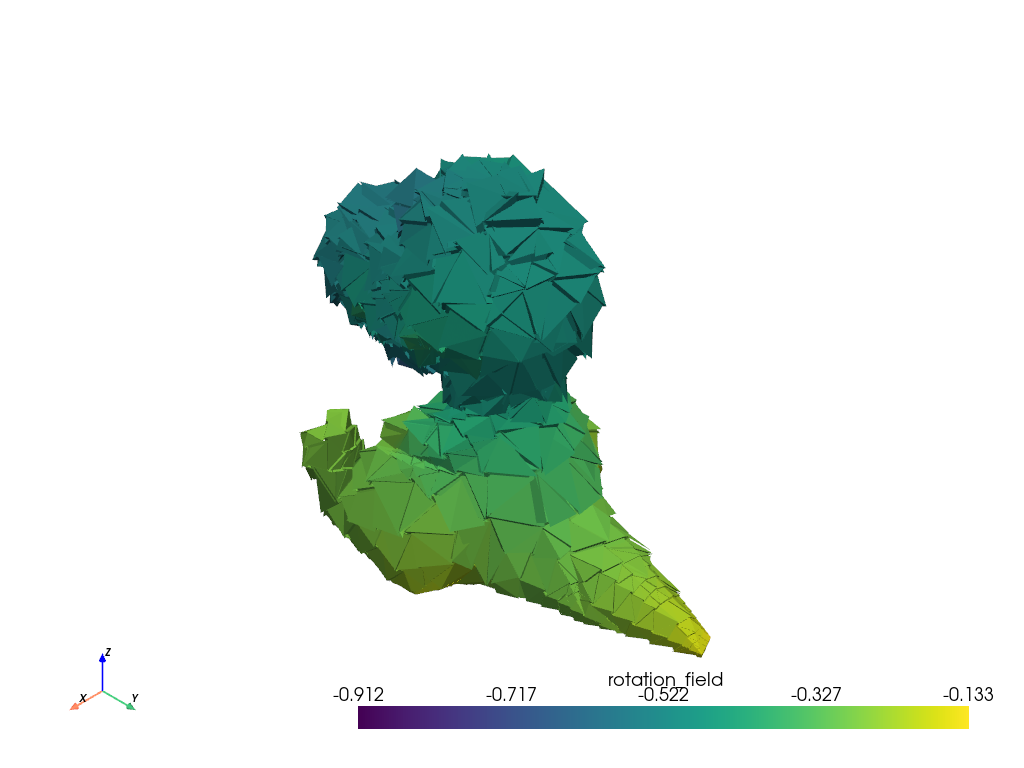

In [28]:

def calculate_initial_rotation_field(tet, MAX_OVERHANG, ROTATION_MULTIPLIER, STEEP_OVERHANG_COMPENSATION, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO, MAX_POS_ROTATION, MAX_NEG_ROTATION):
    '''
    Calculate the initial rotation field for each cell in the tetrahedral mesh to make overhangs less than MAX_OVERHANG.
    The direction of rotation ensures the part is printable.
    '''

    # create initial rotation field rotating faces to be in safe printing angle
    initial_rotation_field = np.full((tet.number_of_cells), np.nan)
    initial_rotation_field = np.abs(np.deg2rad(90+MAX_OVERHANG) - tet.cell_data['overhang_angle'])

    path_length_to_base_gradient = calculate_path_length_to_base_gradient(tet, MAX_OVERHANG, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO)

    # if path_length_to_base_gradient is different to the cell's overhang direction, it needs to be rotated an additional amount (its overhang angle) to make it go the right way
    # Put behind a flag because it is normally not needed, and buggy/finnicky
    # Can try enable it for models with very steep overhangs (>90 degrees) (not common)
    if STEEP_OVERHANG_COMPENSATION:
        initial_rotation_field[tet.cell_data["in_air"]] += 2 * (np.deg2rad(180) - tet.cell_data['overhang_angle'][tet.cell_data["in_air"]])

    # # Apply the path_length_to_base_gradient (optimal overhang direction) to the initial rotation field
    initial_rotation_field *= path_length_to_base_gradient

    # apply rotation multiplier
    initial_rotation_field = np.clip(initial_rotation_field*ROTATION_MULTIPLIER, -np.deg2rad(360), np.deg2rad(360))

    # clip to max rotation
    initial_rotation_field = np.clip(initial_rotation_field, MAX_NEG_ROTATION, MAX_POS_ROTATION)

    tet.cell_data["initial_rotation_field"] = initial_rotation_field

    return initial_rotation_field

from scipy.sparse import lil_matrix

def calculate_rotation_matrices(tet, rotation_field):
    '''
    Calculate the rotation matrices for each cell in the tetrahedral mesh given the scalar
    rotation field that gives a rotation for each cell. Cells are rotated around the axis
    perpendicular to the radial direction and the z-axis.
    '''

    # create rotation matrix from theta around axis
    tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])
    # normalize
    tangential_vectors /= np.linalg.norm(tangential_vectors, axis=1)[:, None]
    # replace nan with [1,0,0]
    tangential_vectors[np.isnan(tangential_vectors).any(axis=1)] = [1, 0, 0]

    rotation_matrices = R.from_rotvec(rotation_field[:, None] * tangential_vectors).as_matrix()

    return rotation_matrices

def calculate_unique_vertices_rotated(tet, rotation_field):
    '''
    Calculate the vertices of a tetrahedral mesh after rotating each cell by the rotation field.
    Vertices are unique: they are not shared between cells.
    '''

    rotation_matrices = calculate_rotation_matrices(tet, rotation_field)

    # rotate each face by the rotation field around its center
    unique_vertices = np.zeros((tet.number_of_cells, 4, 3))
    for cell_index, cell in enumerate(tet.field_data["cells"]):
        unique_vertices[cell_index] = tet.field_data["cell_vertices"][cell]

    cell_centers = tet.cell_data["cell_center"]

    unique_vertices_rotated = cell_centers.reshape(-1, 1, 3, 1) + rotation_matrices.reshape(-1, 1, 3, 3) @ (unique_vertices.reshape(-1, 4, 3, 1) - cell_centers.reshape(-1, 1, 3, 1))
    # unique_vertices_rotated = rotation_matrices.reshape(-1, 1, 3, 3) @ unique_vertices.reshape(-1, 4, 3, 1)

    return unique_vertices_rotated

def apply_rotation_field_unique_vertices(tet, rotation_field):
    '''
    Apply the rotation field to the tetrahedral mesh and return a new tetrahedral mesh.
    Vertices are unique: they are not shared between cells.
    '''

    unique_vertices_rotated = calculate_unique_vertices_rotated(tet, rotation_field)

    unique_cells = np.zeros((tet.number_of_cells, 5), dtype=int)
    unique_cells[:, 0] = 4
    unique_cells[:, 1:] = np.arange(tet.number_of_cells*4).reshape(-1, 4)

    new_tet = pv.UnstructuredGrid(unique_cells.flatten(), np.full(tet.number_of_cells, pv.CellType.TETRA), unique_vertices_rotated.reshape(-1, 3))

    return new_tet

def apply_rotation_field(tet, rotation_field):
    '''
    Apply the rotation field to the tetrahedral mesh and return a new tetrahedral mesh.
    Vertices are shared between cells, so the surface is closed and smooth.
    '''

    new_vertices = np.zeros((tet.number_of_points, 3))
    vertices_count = np.zeros((tet.number_of_points))
    for cell in tet.field_data["cells"]:
        vertices_count[cell] += 1

    unique_vertices_rotated = calculate_unique_vertices_rotated(tet, rotation_field)

    for cell_index, vertices in enumerate(unique_vertices_rotated):
        for i, vertex in enumerate(vertices):
            new_vertices[tet.field_data["cells"][cell_index, i]] += vertex.T[0] / vertices_count[tet.field_data["cells"][cell_index][i]]

    new_tet = pv.UnstructuredGrid(tet.cells, np.full(tet.number_of_cells, pv.CellType.TETRA), new_vertices)

    return new_tet


def optimize_rotations(tet, NEIGHBOUR_LOSS_WEIGHT, MAX_OVERHANG, ROTATION_MULTIPLIER, ITERATIONS, SAVE_GIF, STEEP_OVERHANG_COMPENSATION, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO, MAX_POS_ROTATION, MAX_NEG_ROTATION):
    '''
    Optimize the rotation field for each cell in the tetrahedral mesh to make overhangs less
    than MAX_OVERHANG while keeping the rotation field smooth.
    '''

    imgs = []
    plotter = pv.Plotter(off_screen=True)
    if SAVE_GIF:
        plotter.open_gif(f'gifs/{model_name}_optimize_rotations.gif')

    initial_rotation_field = calculate_initial_rotation_field(tet, MAX_OVERHANG, ROTATION_MULTIPLIER, STEEP_OVERHANG_COMPENSATION, INITIAL_ROTATION_FIELD_SMOOTHING, SET_INITIAL_ROTATION_TO_ZERO, MAX_POS_ROTATION, MAX_NEG_ROTATION)
    num_cells_with_initial_rotation = np.sum(~np.isnan(initial_rotation_field))

    def save_gif(rotation_field):
        new_tet = apply_rotation_field_unique_vertices(tet, rotation_field)
        new_tet.cell_data["rotation_field"] = rotation_field
        mesh_actor = plotter.add_mesh(new_tet,  clim=[-np.pi/4, np.pi/4], scalars="rotation_field", lighting=False)
        plotter.write_frame()
        plotter.remove_actor(mesh_actor)

    def objective_function(rotation_field):
        '''
        Objective function to minimize the neighbour losses and initial rotation losses.
        '''
        if SAVE_GIF:
            save_gif(rotation_field)

        # Compute neighbour losses using vectorized operations
        cell_face_neighbours = tet.field_data["cell_face_neighbours"]
        neighbour_differences = rotation_field[cell_face_neighbours[:, 0]] - rotation_field[cell_face_neighbours[:, 1]]
        neighbour_losses = NEIGHBOUR_LOSS_WEIGHT * neighbour_differences**2

        # Compute the initial rotation losses
        overhanging_mask = tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)
        valid_cell_indices = np.where(~np.isnan(initial_rotation_field))[0]#np.where(overhanging_mask)[0]
        initial_rotation_losses = (rotation_field[valid_cell_indices] - initial_rotation_field[valid_cell_indices])**2

        # Return the concatenated losses
        return np.concatenate((neighbour_losses, initial_rotation_losses))


    def objective_jacobian(rotation_field):
        start_time = time.time()
        # Initialize the sparse matrix with LIL format for efficient row-wise operations
        cell_face_neighbours = tet.field_data["cell_face_neighbours"]
        jac = lil_matrix((len(cell_face_neighbours) + num_cells_with_initial_rotation, tet.number_of_cells), dtype=np.float32)

        # Vectorized computation for neighbour loss derivatives
        cell_1 = cell_face_neighbours[:, 0]
        cell_2 = cell_face_neighbours[:, 1]

        # Compute the differences
        differences = rotation_field[cell_1] - rotation_field[cell_2]

        # Fill in the Jacobian for the first derivative of the neighbour loss function
        jac[range(len(cell_face_neighbours)), cell_1] = 2 * NEIGHBOUR_LOSS_WEIGHT * differences
        jac[range(len(cell_face_neighbours)), cell_2] = -2 * NEIGHBOUR_LOSS_WEIGHT * differences

        # Vectorized computation for initial rotation loss derivatives
        overhanging_mask = tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)
        valid_cell_indices = np.where(~np.isnan(initial_rotation_field))[0]#np.where(overhanging_mask)[0]

        # Fill in the Jacobian for the first derivative of the initial rotation loss function
        jac[len(cell_face_neighbours) + np.arange(len(valid_cell_indices)), valid_cell_indices] = \
            2 * (rotation_field[valid_cell_indices] - initial_rotation_field[valid_cell_indices])

        # print("Jacobian time:", time.time() - start_time)
        # Convert the LIL matrix to CSR format for efficient computations in further steps
        return jac.tocsr()

    def jac_sparsity():
        cell_face_neighbours = tet.field_data["cell_face_neighbours"]
        sparsity = lil_matrix((len(cell_face_neighbours) + num_cells_with_initial_rotation, tet.number_of_cells), dtype=np.int8)

        for i, (cell_1, cell_2) in enumerate(cell_face_neighbours):
            sparsity[i, cell_1] = 1
            sparsity[i, cell_2] = 1

        valid_cell_indices = np.where(~np.isnan(initial_rotation_field))[0]#np.where(overhanging_mask)[0]
        i = 0
        for cell_index, initial_rotation in enumerate(initial_rotation_field):
            if cell_index in valid_cell_indices:
                sparsity[len(cell_face_neighbours) + i, cell_index] = 1
                i += 1

        return sparsity.tocsr()

    smoothed_rotation_field = np.zeros((tet.number_of_cells))

    # Optimization process to smooth the initial rotation field
    result = least_squares(objective_function,
                    smoothed_rotation_field,
                    jac=objective_jacobian,
                    max_nfev=ITERATIONS,
                    jac_sparsity=jac_sparsity(),
                    verbose=2,
                    method='trf',
                    ftol=1e-6,
                    )

    # render array of numpy images (imgs) into gif
    if SAVE_GIF:
        plotter.close()

    return result.x

NEIGHBOUR_LOSS_WEIGHT = 20 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 30          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 2   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = False # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
MAX_POS_ROTATION = np.deg2rad(3600) # normally set to 360 unless you get collisions
MAX_NEG_ROTATION = np.deg2rad(-3600) # normally set to 360 unless you get collisions
ITERATIONS = 100
SAVE_GIF = True
STEEP_OVERHANG_COMPENSATION = True

rotation_field = optimize_rotations(
    undeformed_tet,
    NEIGHBOUR_LOSS_WEIGHT,
    MAX_OVERHANG,
    ROTATION_MULTIPLIER,
    ITERATIONS,
    SAVE_GIF,
    STEEP_OVERHANG_COMPENSATION,
    INITIAL_ROTATION_FIELD_SMOOTHING,
    SET_INITIAL_ROTATION_TO_ZERO,
    MAX_POS_ROTATION,
    MAX_NEG_ROTATION
)
# rotation_field = calculate_initial_rotation_field(tet, MAX_OVERHANG, ROTATION_MULTIPLIER)
undeformed_tet_with_rotated_tetrahedrons = apply_rotation_field_unique_vertices(undeformed_tet, rotation_field)
undeformed_tet_with_rotated_tetrahedrons.cell_data["rotation_field"] = rotation_field
# new_tet.extract_cells(np.where(rotation_field != 0)[0]).plot()
undeformed_tet_with_rotated_tetrahedrons.plot(scalars="rotation_field")

default
```
NEIGHBOUR_LOSS_WEIGHT = 20 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 30          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 2   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = False # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
```

benchy upsidedown tilted
scale: 1.5
Iteration 1:
```
NEIGHBOUR_LOSS_WEIGHT = 100 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 5          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 1   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = True # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
```

Iteration 2:
```
NEIGHBOUR_LOSS_WEIGHT = 50 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 5          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 1   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = True # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
```

Iteration 3,4,5:
```
NEIGHBOUR_LOSS_WEIGHT = 50 # the larger the weight, the more the rotation field will be smoothed
MAX_OVERHANG = 50          # the maximum overhang angle in degrees
ROTATION_MULTIPLIER = 3   # the larger the multiplier, the more the rotation field will be rotated
SET_INITIAL_ROTATION_TO_ZERO = True # reduces influence of initial rotation field on non-overhanging tetrahedrons. good when initial rotation field is noisy
INITIAL_ROTATION_FIELD_SMOOTHING = 30
```

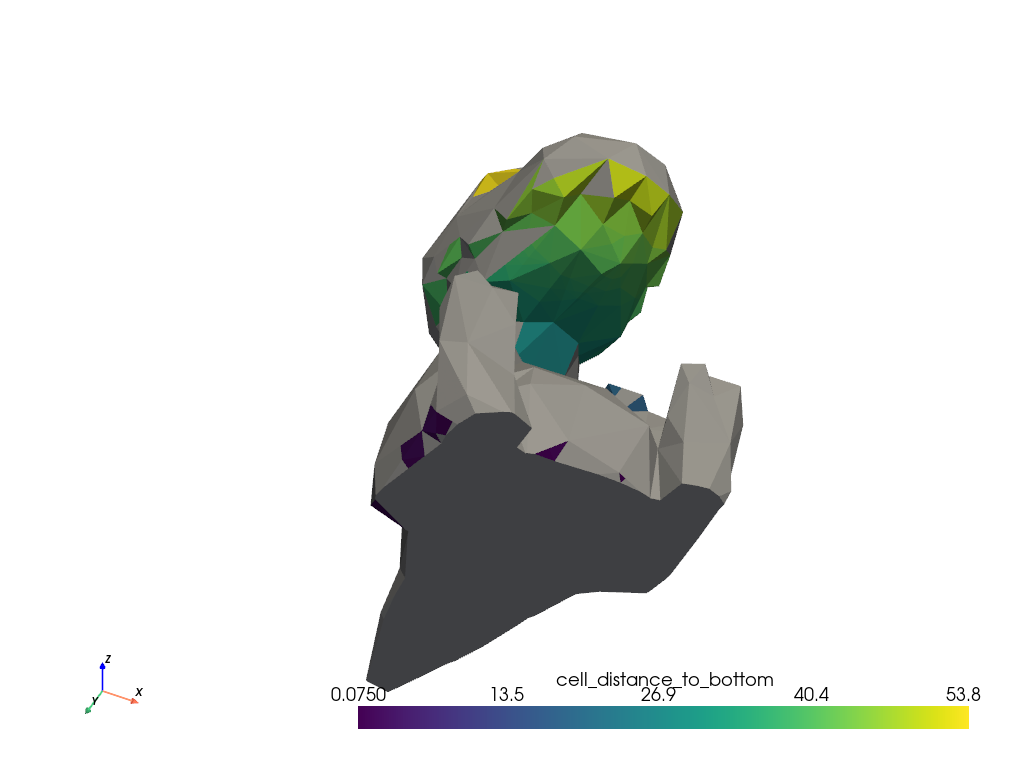

In [29]:
# view the initial rotation field we are trying to optimize towards
# tet.extract_cells(tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)).plot(scalars="initial_rotation_field")
# tet.cell_data['overhang_angle'] > np.deg2rad(90 + MAX_OVERHANG)
# undeformed_tet.plot(scalars="initial_rotation_field")
# undeformed_tet.plot(scalars="in_air")
undeformed_tet.plot(scalars="cell_distance_to_bottom", cpos=[-0.5, -1, -1])
# undeformed_tet.plot(scalars="overhang_angle")
# undeformed_tet.plot(scalars="path_length_to_base_gradient")
# undeformed_tet.plot(scalars=new_tet1.cell_data['rotation_field'])

def show_path_to_base(tet, cell_index, plotter=pv.Plotter()):
    path_to_bottom = tet.cell_data['path_to_bottom'][cell_index]
    first_negative_index = np.where(path_to_bottom == -1)[0][0]
    path_to_bottom = path_to_bottom[:first_negative_index]
    print(path_to_bottom)

    for i in range(len(path_to_bottom)-1):
        path_to_base = pv.Line(tet.cell_data["cell_center"][path_to_bottom[i]], tet.cell_data["cell_center"][path_to_bottom[i+1]])
        plotter.add_mesh(path_to_base, color="red")

    plotter.add_mesh(tet, opacity=0.2)
    plotter.show()

# show_path_to_base(tet, np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > 3))[0][7])

def show_path_to_base_gradient_calculation(tet, cell_indices):
    plotter = pv.Plotter()
    scalar = np.full(tet.number_of_cells, 0.0)

    for cell_index in cell_indices:
        local_cells = cell_neighbour_dict["edge"][cell_index]
        local_cells = np.hstack((local_cells, cell_index))
        local_cells_with_path_lengths = [x for x in local_cells if not np.isnan(tet.cell_data['cell_distance_to_bottom'][x])]
        path_lengths = tet.cell_data['cell_distance_to_bottom'][local_cells_with_path_lengths]

        cell_centers = tet.cell_data["cell_center"][local_cells_with_path_lengths]
        cell_centers_z_is_path_length = cell_centers.copy()
        cell_centers_z_is_path_length[:, 2] = path_lengths - np.min(path_lengths) + np.min(cell_centers[:, 2])
        points = pv.PolyData(cell_centers_z_is_path_length)
        glyph = points.glyph(geom=pv.Sphere(theta_resolution=8, phi_resolution=8, radius=0.1))

        if len(cell_centers_z_is_path_length) < 3:
            continue

        p, n = planeFit(cell_centers_z_is_path_length.T)
        plane = pv.Plane(center=p, direction=n, i_size=4, j_size=4)
        normal_arrow = pv.Arrow(start=p, direction=n, scale=1.5)

        # reflect arrow across xy plane
        reflected_n = -n - 2 * (np.dot(-n, up_vector)) * up_vector

        # extract radial component
        cell_center_direction_normalized = tet.cell_data["cell_center"][cell_index, :2] / np.linalg.norm(tet.cell_data["cell_center"][cell_index, :2])
        gradient_in_radial_direction = np.dot(cell_center_direction_normalized, reflected_n[:2]) * cell_center_direction_normalized
        nozzle_arrow = pv.Arrow(start=tet.cell_data["cell_center"][cell_index], direction=np.hstack((gradient_in_radial_direction, reflected_n[2])), scale=1)


        # plotter.add_mesh(glyph, color="blue", opacity=0.5, )
        # plotter.add_mesh(plane, color="green", opacity=0.2)
        # plotter.add_mesh(normal_arrow, color="orange")
        plotter.add_mesh(nozzle_arrow, color="red")
    scalar[local_cells_with_path_lengths] = 0.5
    scalar[cell_index] = 1
    plotter.add_mesh(tet, opacity=0.2, scalars=scalar, cmap="binary")
    plotter.show()

# show_path_to_base_gradient_calculation(undeformed_tet, [np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > 3))[0][1]])
# show_path_to_base_gradient_calculation(undeformed_tet, np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > np.deg2rad(90 + MAX_OVERHANG)))[0])

def show_dijkstras(tet, cell_index):
    plotter = pv.Plotter()#window_size=[3840, 2160])
    lines = []
    for neighbour in tet.field_data["cell_face_neighbours"]:
        lines += [tet.cell_data["cell_center"][neighbour[0]], tet.cell_data["cell_center"][neighbour[1]]]
    mesh = pv.line_segments_from_points(lines)
    plotter.add_mesh(mesh, color="grey", opacity=0.4)

    points = pv.PolyData(tet.cell_data["cell_center"])
    glyph = points.glyph(geom=pv.Sphere(theta_resolution=8, phi_resolution=8, radius=0.1))
    plotter.add_mesh(glyph, color="red", opacity=0.2)

    if cell_index is None:
        plotter.show()
        return

    plotter.camera_position = "xz"

    # run dijkstra's algorithm and visualize
    plotter.open_gif(f'gifs/{model_name}_dijkstra.gif')
    distances, paths = nx.single_source_dijkstra(cell_neighbour_graph, cell_index)
    dijkstra_actors = []
    for i in np.arange(0, tet.cell_data['cell_distance_to_bottom'][cell_index], 0.2):
        nodes_in_range = [node for node, distance in distances.items() if distance < i]
        if len(nodes_in_range) == 0:
            continue
        if set(nodes_in_range) & set(bottom_cells):
            break
        points = pv.PolyData(tet.cell_data["cell_center"][nodes_in_range])
        glyph = points.glyph(geom=pv.Sphere(theta_resolution=8, phi_resolution=8, radius=0.2))
        actor = plotter.add_mesh(glyph, color="blue", opacity=0.4)
        dijkstra_actors.append(actor)
        plotter.write_frame()


    path_to_bottom = tet.cell_data['path_to_bottom'][cell_index]
    first_negative_index = np.where(path_to_bottom == -1)[0][0]
    path_to_bottom = path_to_bottom[:first_negative_index]
    print(path_to_bottom)

    for i in range(len(path_to_bottom)-1):
        path_to_base = pv.Line(tet.cell_data["cell_center"][path_to_bottom[i]], tet.cell_data["cell_center"][path_to_bottom[i+1]])
        plotter.add_mesh(path_to_base, color="blue", line_width=5)

    for actor in dijkstra_actors:
        plotter.remove_actor(actor)

    plotter.write_frame()

    plotter.show()
    plotter.close()


# show_dijkstras(undeformed_tet, np.where(tet.cell_data['has_face'].astype(bool) & (tet.cell_data["overhang_angle"] > 3))[0][1])

/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         9.0030e+04                                    3.16e+03    
       1              6         8.8582e+04      1.45e+03       1.24e+00       3.12e+03    
       2              7         8.5716e+04      2.87e+03       1.58e+00       3.04e+03    
       3              8         8.0574e+04      5.14e+03       2.75e+00       2.87e+03    
       4              9         7.2491e+04      8.08e+03       5.02e+00       2.57e+03    
       5             10         6.3453e+04      9.04e+03       9.65e+00       2.34e+03    
       6             11         5.2793e+04      1.07e+04       8.28e+00       1.81e+03    
       7             12         4.5110e+04      7.68e+03       8.35e+00       1.55e+03    
       8             13         3.9832e+04      5.28e+03       8.38e+00       1.31e+03    
       9             14         3.5533e+04      4.30e+03       8.30e+00       1.11e+03    

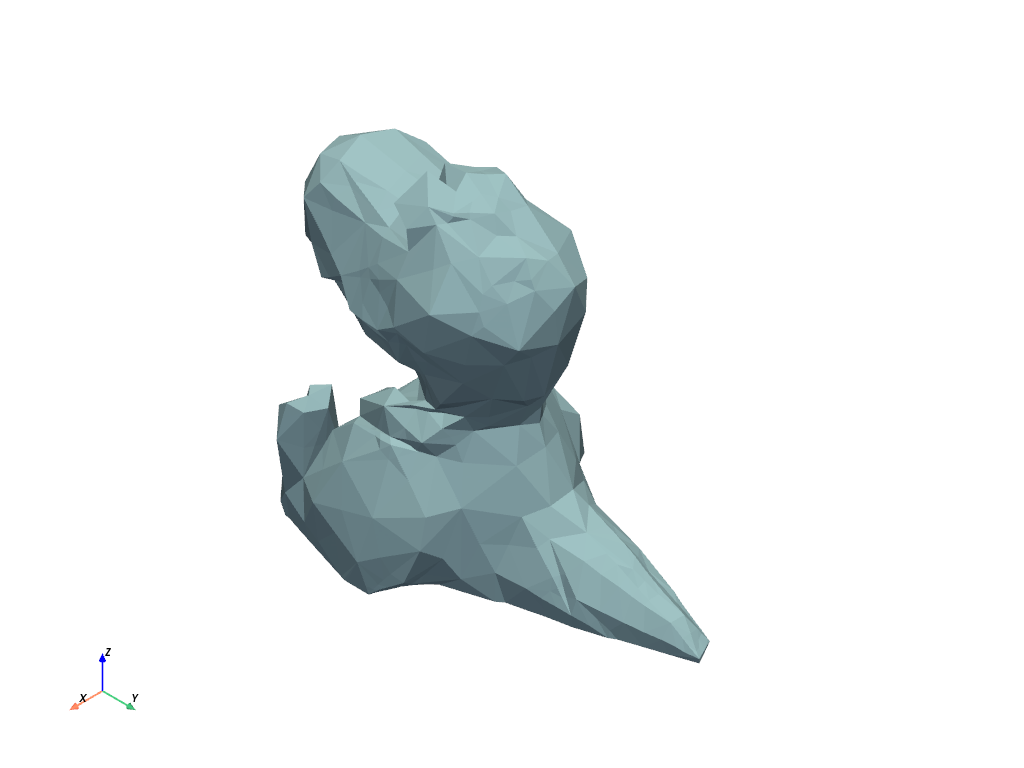

/tmp/ipykernel_4680/636589049.py:78: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()


In [30]:
N = np.eye(4) - 1/4 * np.ones((4, 4))

save_gif_i = 0

def calculate_deformation(tet, rotation_field, ITERATIONS, SAVE_GIF, pin_bottom=True):
    '''
    Find the optimal deformation of the tetrahedral mesh while optionally pinning the bottom layer.
    '''

    new_vertices = tet.points.copy()
    params = new_vertices.flatten()

    rotation_matrices = calculate_rotation_matrices(tet, rotation_field)
    old_vertices = tet.field_data["cell_vertices"][tet.field_data["cells"]]
    old_vertices_transformed = np.einsum('ijk,ikl->ijl', rotation_matrices, (N @ old_vertices).transpose(0, 2, 1))

    plotter = pv.Plotter(off_screen=True)
    if SAVE_GIF:
        plotter.open_gif(f'gifs/{model_name}_calculate_deformation.gif')

    # Identify vertices on the bottom layer to pin them later
    z_min = np.min(tet.points[:, 2])
    bottom_vertex_mask = np.abs(tet.points[:, 2] - z_min) < 0.1
    bottom_vertex_indices = np.where(bottom_vertex_mask)[0]

    def save_gif(new_vertices):
        global save_gif_i
        save_gif_i += 1
        if save_gif_i % 10 != 0: return
        new_tet = pv.UnstructuredGrid(tet.cells, np.full(tet.number_of_cells, pv.CellType.TETRA), new_vertices)
        mesh_actor = plotter.add_mesh(new_tet)
        plotter.write_frame()
        plotter.remove_actor(mesh_actor)

    def objective_function(params):
        new_vertices = params.reshape(-1, 3)
        if SAVE_GIF: save_gif(new_vertices)

        new_vertices_transformed = (N @ new_vertices[tet.field_data["cells"]]).transpose(0, 2, 1)
        position_losses = np.linalg.norm(new_vertices_transformed - old_vertices_transformed, axis=(1, 2))**2

        if pin_bottom:
            # Add a heavy penalty for bottom vertices moving away from Z=z_min
            pin_loss = 1000 * (new_vertices[bottom_vertex_indices, 2] - z_min)**2
            return np.concatenate((position_losses, pin_loss))

        return position_losses

    def objective_jacobian(params):
        new_vertices = params.reshape(-1, 3)
        diff = (N @ new_vertices[tet.field_data["cells"]]).transpose(0, 2, 1) - old_vertices_transformed
        diff = diff.transpose(0, 2, 1)

        rows = tet.number_of_cells + (len(bottom_vertex_indices) if pin_bottom else 0)
        J = lil_matrix((rows, len(params)), dtype=np.float32)

        cell_indices = np.repeat(np.arange(tet.number_of_cells), 4)
        vertex_indices = np.ravel(tet.field_data["cells"])

        for dim in range(3):
            J[cell_indices, vertex_indices * 3 + dim] = 2 * diff[:, :, dim].ravel()

        if pin_bottom:
            for i, v_idx in enumerate(bottom_vertex_indices):
                # Derivative of 1000 * (v_z - z_min)^2 w.r.t v_z is 2000 * (v_z - z_min)
                J[tet.number_of_cells + i, v_idx * 3 + 2] = 2000 * (new_vertices[v_idx, 2] - z_min)

        return J.tocsr()

    def jac_sparsity():
        rows = tet.number_of_cells + (len(bottom_vertex_indices) if pin_bottom else 0)
        sparsity = lil_matrix((rows, len(params)), dtype=np.int8)
        cell_indices = np.repeat(np.arange(tet.number_of_cells), 4)
        vertex_indices = np.ravel(tet.field_data["cells"])
        for dim in range(3):
            sparsity[cell_indices, vertex_indices * 3 + dim] = 1
        if pin_bottom:
            for i, v_idx in enumerate(bottom_vertex_indices):
                sparsity[tet.number_of_cells + i, v_idx * 3 + 2] = 1
        return sparsity.tocsr()

    result = least_squares(objective_function,
                    params,
                    max_nfev=ITERATIONS,
                    verbose=2,
                    jac=objective_jacobian,
                    jac_sparsity=jac_sparsity(),
                    method='trf',
                    x_scale='jac',
                    )
    plotter.close()
    return result.x.reshape(-1, 3)

ITERATIONS = 1000
SAVE_GIF = True
new_vertices = calculate_deformation(undeformed_tet, rotation_field, ITERATIONS, SAVE_GIF, pin_bottom=True)
deformed_tet = pv.UnstructuredGrid(undeformed_tet.cells, np.full(undeformed_tet.number_of_cells, pv.CellType.TETRA), new_vertices)
deformed_tet.plot()

for key in undeformed_tet.field_data.keys():
    deformed_tet.field_data[key] = undeformed_tet.field_data[key]
for key in undeformed_tet.cell_data.keys():
    deformed_tet.cell_data[key] = undeformed_tet.cell_data[key]
deformed_tet = update_tet_attributes(deformed_tet)

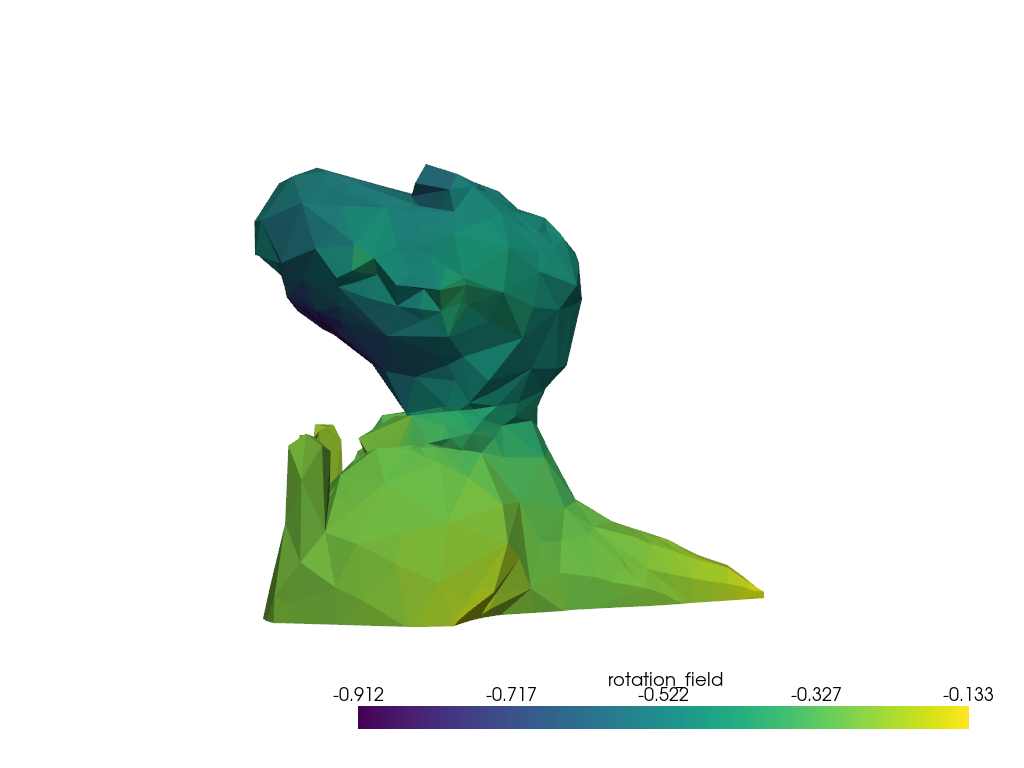

In [31]:
# View from the side (90 degree rotation from previous front view)
plotter = pv.Plotter()
deformed_tet.cell_data['rotation_field'] = rotation_field
plotter.add_mesh(deformed_tet, scalars="rotation_field")
# 'yz' provides a 90-degree side view compared to 'xz'
plotter.camera_position = 'yz'
plotter.show(title="Side View - 90 Degree Rotation")

Run below to do another iteration

In [32]:
undeformed_tet = deformed_tet.copy()

Run below when finished deforming to save mesh as STL

In [33]:
# make origin center bottom of bounding box
x_min, x_max, y_min, y_max, z_min, z_max = deformed_tet.bounds
offsets_applied = np.array([(x_min + x_max) / 2, (y_min + y_max) / 2, z_min])
deformed_tet.points -= offsets_applied

deformed_tet.extract_surface().save(f'output_models/{model_name}_deformed_tet.stl')

/tmp/ipykernel_4680/666307734.py:6: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  deformed_tet.extract_surface().save(f'output_models/{model_name}_deformed_tet.stl')


In [34]:

# save to pickle
with open(f'pickle_files/deformed_{model_name}.pkl', 'wb') as f:
    pickle.dump(deformed_tet, f)

# Now, go and slice the stl file in Cura!

Settings:
- Make the printer origin at the center of the buildplate
- Dont use any pre/post scripts, z hop, etc. The config I use is provided in the github repo
- Autoplace the model at the center by clicking "Arrange All Models"

In [35]:

deformed_tet = pickle.load(open(f'pickle_files/deformed_{model_name}.pkl', 'rb'))

In [36]:
def tetrahedron_volume(p1, p2, p3, p4):
    '''
    Calculate the volume of the tetrahedron formed by four points
    '''

    mat = np.vstack([p2 - p1, p3 - p1, p4 - p1])
    return np.abs(np.linalg.det(mat)) / 6

def calc_barycentric_coordinates(tet_a, tet_b, tet_c, tet_d, point):
    '''
    Calculate the barycentric coordinates of a point in a tetrahedron. This is used to interpolate
    parameters from the vertices of the tetrahedron to a point within the tetrhedron.
    '''

    total_volume = tetrahedron_volume(tet_a, tet_b, tet_c, tet_d)

    if total_volume == 0:
        raise ValueError("The points do not form a valid tetrahedron (zero volume).")

    # Calculate the sub-volumes for each face
    vol_a = tetrahedron_volume(point, tet_b, tet_c, tet_d)
    vol_b = tetrahedron_volume(point, tet_a, tet_c, tet_d)
    vol_c = tetrahedron_volume(point, tet_a, tet_b, tet_d)
    vol_d = tetrahedron_volume(point, tet_a, tet_b, tet_c)

    # Calculate barycentric coordinates as the ratio of sub-volumes to total volume
    lambda_a = vol_a / total_volume
    lambda_b = vol_b / total_volume
    lambda_c = vol_c / total_volume
    lambda_d = vol_d / total_volume

    # The barycentric coordinates should sum to 1
    return np.array([lambda_a, lambda_b, lambda_c, lambda_d])

def project_point_onto_plane(plane_x_axis, plane_y_axis, point):
    projected_x = np.sum(plane_x_axis * point, axis=1)
    projected_y = np.sum(plane_y_axis * point, axis=1)

    return np.array([projected_x, projected_y]).T

In [37]:
deformed_tet, _, _ = calculate_tet_attributes(deformed_tet)

/tmp/ipykernel_4680/636589049.py:152: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()
/tmp/ipykernel_4680/636589049.py:78: PyVistaFutureWarning: The default value of `algorithm` for the filter
`UnstructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  surface_mesh = tet.extract_surface()


In [38]:
from pygcode import Line
import time

SEG_SIZE = 0.6 # mm
MAX_ROTATION = 30 # degrees
MIN_ROTATION = -130 # degrees
NOZZLE_OFFSET = 48.6 # mm

# find how each vertex in tet has been transformed
vertex_transformations = deformed_tet.points - input_tet.points

# calculate tangential vectors (axis of rotation) for each cell
tangential_vectors = np.cross( np.array([0, 0, 1]), input_tet.cell_data["cell_center"][:, :2])
# normalize
tangential_vectors /= np.linalg.norm(tangential_vectors, axis=1)[:, None]
# replace nan with [1,0,0]
tangential_vectors[np.isnan(tangential_vectors).any(axis=1)] = [1, 0, 0]

# calculate rotation for each vertex and cell
num_cells_per_vertex = np.zeros((input_tet.number_of_points))
for cell_index, cell in enumerate(input_tet.field_data["cells"]):
    num_cells_per_vertex[cell] += 1
vertex_rotations = np.zeros((deformed_tet.number_of_points))
cell_rotations = np.zeros((deformed_tet.number_of_cells))
for cell_index, cell in enumerate(deformed_tet.field_data["cells"]):
    new_vertices = deformed_tet.field_data["cell_vertices"][cell]
    new_cell_center = deformed_tet.cell_data["cell_center"][cell_index]
    old_vertices = input_tet.field_data["cell_vertices"][cell]
    old_cell_center = input_tet.cell_data["cell_center"][cell_index]

    # center points
    new_vertices -= new_cell_center
    old_vertices -= old_cell_center

    # project on to radial plane
    plane_x_vector = old_cell_center[:2] / np.linalg.norm(old_cell_center[:2])
    plane_x_vector = np.array([plane_x_vector[0], plane_x_vector[1], 0])
    plane_y_vector = np.array([0,0,1])

    new_vertices_projected = project_point_onto_plane(plane_x_vector, plane_y_vector, new_vertices)
    old_vertices_projected = project_point_onto_plane(plane_x_vector, plane_y_vector, old_vertices)

    # find rotation between the two sets of points using the kabsch algorithm
    covariance_matrix = np.dot(new_vertices_projected.T, old_vertices_projected)
    U, _, Vt = np.linalg.svd(covariance_matrix)
    rotation_matrix = np.dot(U, Vt)

    # get rotation angle from matrix 2x2
    rotation = -np.arccos(min(max(rotation_matrix[0, 0], -1), 1))
    if rotation_matrix[1, 0] < 0:
        rotation = -rotation

    rotation = max(min(rotation, np.deg2rad(MAX_ROTATION)), np.deg2rad(MIN_ROTATION))

    cell_rotations[cell_index] = rotation

    for vertex_index in cell:
        vertex_rotations[vertex_index] += rotation / num_cells_per_vertex[vertex_index]

# calculate z squish scale for each cell (ratio of z length after rotation to z length before rotation)
tet_rotation_matrices = calculate_rotation_matrices(input_tet, cell_rotations)
z_squish_scales = np.full((deformed_tet.number_of_cells), np.nan)
for cell_index, cell in enumerate(deformed_tet.field_data["cells"]):
    warped_vertices = deformed_tet.field_data["cell_vertices"][cell]
    unwarped_vertices = input_tet.field_data["cell_vertices"][cell]

    # rotate new vertices to align with old vertices
    unwarped_vertices_rotated = (tet_rotation_matrices[cell_index].reshape(1, 3, 3) @ unwarped_vertices.reshape(4, 3, 1)).reshape(4, 3)

    # calculate z squish scale
    z_squish_scales[cell_index] = tetrahedron_volume(*unwarped_vertices) / tetrahedron_volume(*warped_vertices)

# read gcode
pos = np.array([0., 0., 20.])
feed = 5000
gcode_points = []
with open(f'input_gcode/{model_name}_deformed_tet.gcode', 'r') as fh:
    for line_text in fh.readlines():
        try:
            line = Line(line_text)
        except:
            # Skip lines that pygcode cannot parse (header metadata, etc)
            continue

        if not line.block.gcodes:
            continue

        for gcode in sorted(line.block.gcodes):
            if gcode.word == "G01" or gcode.word == "G00":
                prev_pos = pos.copy()

                if gcode.X is not None: pos[0] = gcode.X
                if gcode.Y is not None: pos[1] = gcode.Y
                if gcode.Z is not None: pos[2] = gcode.Z

                inv_time_feed = None
                for word in line.block.words:
                    if word.letter == "F": feed = word.value

                extrusion = None
                for param in line.block.modal_params:
                    if param.letter == "E": extrusion = param.value

                delta_pos = pos - prev_pos
                distance = np.linalg.norm(delta_pos)
                if distance > 0:
                    num_segments = -(-distance // SEG_SIZE)
                    seg_distance = distance/num_segments
                    time_to_complete_move = (1/feed) * seg_distance
                    inv_time_feed = 1/time_to_complete_move if time_to_complete_move != 0 else None

                    for i in range(int(num_segments)):
                        gcode_points.append({
                            "position": (prev_pos + delta_pos * (i+1) / num_segments),
                            "command": gcode.word,
                            "extrusion": extrusion/num_segments if extrusion is not None else None,
                            "inv_time_feed": inv_time_feed,
                            "move_length": seg_distance,
                            "feed": feed,
                            "travelling": extrusion is None or extrusion <= 0
                        })
                else:
                    gcode_points.append({
                        "position": pos.copy(),
                        "command": gcode.word,
                        "extrusion": extrusion,
                        "inv_time_feed": None,
                        "move_length": 0,
                        "feed": feed,
                        "travelling": extrusion is None or extrusion <= 0
                    })

# calculate containing cell for each gcode point
gcode_points_containing_cells = deformed_tet.find_containing_cell([point["position"] for point in gcode_points])
gcode_points_closest_cells = deformed_tet.find_closest_cell([point["position"] for point in gcode_points])

new_gcode_points = []
prev_new_position = None
prev_rotation = 0
ROTATION_AVERAGING_ALPHA = 0.2
ROTATION_MAX_DELTA = np.deg2rad(1)
MAX_EXTRUSION_MULTIPLIER = 10
lost_vertices = []
highest_printed_point = 0

for cell_index, (gcode_point, containing_cell_index) in enumerate(zip(gcode_points, gcode_points_containing_cells)):
    position = gcode_point["position"]
    command = gcode_point["command"]
    inv_time_feed = gcode_point["inv_time_feed"]
    extrusion = gcode_point["extrusion"]

    if containing_cell_index == -1:
        containing_cell_index = gcode_points_closest_cells[cell_index]

    vertiex_indices = deformed_tet.field_data["cells"][containing_cell_index]
    cell_vertices = deformed_tet.field_data["cell_vertices"][vertiex_indices]
    barycentric_coordinates = calc_barycentric_coordinates(cell_vertices[0], cell_vertices[1], cell_vertices[2], cell_vertices[3], position)

    transformation = np.sum(vertex_transformations[vertiex_indices] * barycentric_coordinates[:, None], axis=0)
    new_position = position - transformation
    rotation = np.sum(vertex_rotations[vertiex_indices] * barycentric_coordinates)

    if prev_rotation is not None:
        rotation = ROTATION_AVERAGING_ALPHA * rotation + (1 - ROTATION_AVERAGING_ALPHA) * prev_rotation

    new_gcode_points.append({
        "position": new_position,
        "rotation": rotation,
        "command": command,
        "extrusion": extrusion,
        "inv_time_feed": inv_time_feed,
        "extrusion_multiplier": 1.0,
        "feed": gcode_point["feed"],
        "travelling": gcode_point["travelling"]
    })
    prev_rotation = rotation

print(f"Processed {len(new_gcode_points)} points")

/tmp/ipykernel_4680/4128954577.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), input_tet.cell_data["cell_center"][:, :2])
/tmp/ipykernel_4680/4061739082.py:42: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  tangential_vectors = np.cross( np.array([0, 0, 1]), tet.cell_data["cell_center"][:, :2])


Processed 475539 points


In [43]:
import numpy as np

# Thresholds for engaging B-axis tilt
TILT_THRESHOLD = np.deg2rad(1.0) # Angular threshold
MIN_Z_FOR_TILT = 0.5             # Height threshold (skip first layer/base)

# Apply the suppression logic directly to the data objects for visualization accuracy
for point in new_gcode_points:
    position = point["position"]
    rotation = point["rotation"]

    if not np.all(np.isnan(position)):
        if position[2] < MIN_Z_FOR_TILT or abs(rotation) < TILT_THRESHOLD:
            point["rotation"] = 0.0

# save transformed gcode
with open(f'output_gcode/{model_name}.gcode', 'w') as fh:
    # write header
    fh.write("G94 ; mm/min feed\n")
    fh.write("G28 ; home\n")
    fh.write("M83 ; relative extrusion\n")
    fh.write("G1 E10 ; prime extruder\n")
    fh.write("G90 ; absolute positioning\n")

    # Start at 0,0,20
    fh.write(f"G0 X0 Y0 Z20 B0\n")
    fh.write("G93 ; inverse time feed\n")

    for i, point in enumerate(new_gcode_points):
        position = point["position"]
        rotation = point["rotation"]

        if np.all(np.isnan(position)):
            continue

        if position[2] < 0:
            continue

        z_hop = 0
        if point["travelling"]:
            z_hop = 1

        x = position[0]
        y = position[1]
        z = position[2]

        dist_xy = np.linalg.norm([x, y])
        if dist_xy > 0:
            unit_x = x / dist_xy
            unit_y = y / dist_xy
        else:
            unit_x, unit_y = 1, 0

        # Apply offset based on tilt
        offset_mag = -np.sin(rotation) * (NOZZLE_OFFSET + z_hop)
        x_final = x + unit_x * offset_mag
        y_final = y + unit_y * offset_mag
        z_final = z + (np.cos(rotation) - 1) * (NOZZLE_OFFSET + z_hop) + z_hop

        string = f"{point['command']} X{x_final:.5f} Y{y_final:.5f} Z{z_final:.5f} B{np.rad2deg(rotation):.5f}"

        if point["extrusion"] is not None:
            string += f" E{point['extrusion']:.4f}"

        if point["inv_time_feed"] is not None:
            string += f" F{point['inv_time_feed']:.4f}"
        else:
            string += " F20000"

        fh.write(string + "\n")

In [45]:
from google.colab import files

# Download the generated G-code file
files.download(f'output_gcode/{model_name}.gcode')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

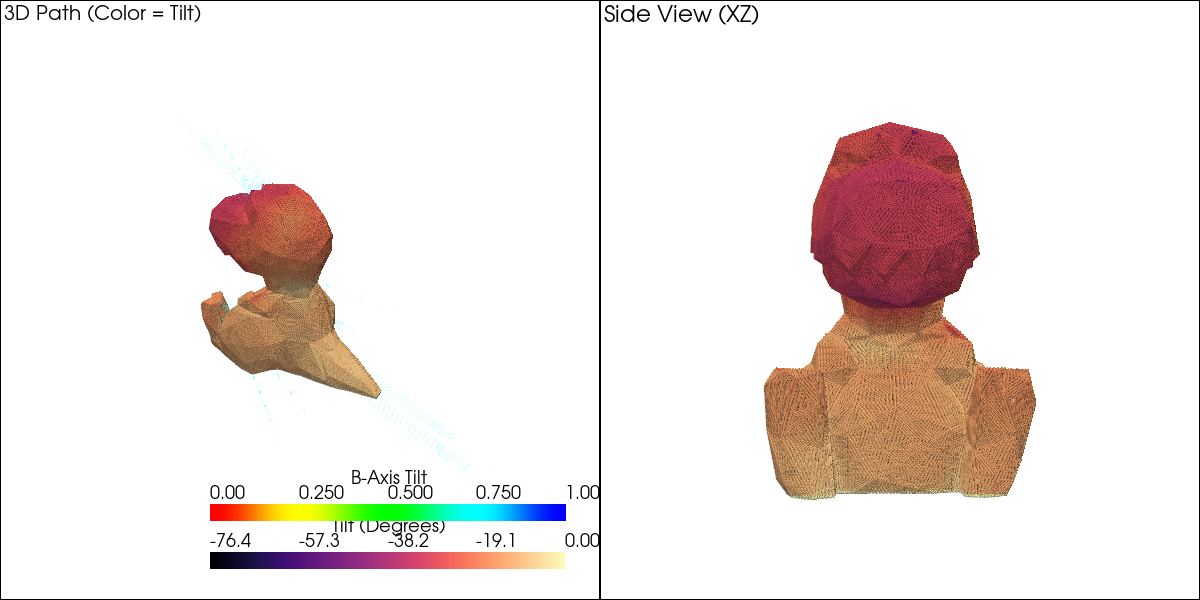

In [49]:
import pyvista as pv
import numpy as np

# Prepare points for visualization
vis_points = []
rotations = []
commands = []

for pt in new_gcode_points:
    if not np.all(np.isnan(pt['position'])):
        vis_points.append(pt['position'])
        rotations.append(np.rad2deg(pt['rotation']))
        commands.append(1 if pt['command'] == 'G01' else 0)

# Create PyVista object
path_poly = pv.PolyData(np.array(vis_points))
path_poly.point_data['Tilt (Degrees)'] = np.array(rotations)
path_poly.point_data['Is_Printing'] = np.array(commands)

# Plot the simulation with a darker theme similar to web viewers
plotter = pv.Plotter(shape=(1, 2), window_size=[1200, 600])
pv.global_theme.color = 'white'

# View 1: 3D Isometric View
plotter.subplot(0, 0)
printing_moves = path_poly.extract_points(path_poly.point_data['Is_Printing'] == 1)
plotter.add_mesh(printing_moves, scalars='Tilt (Degrees)', cmap='magma', render_points_as_spheres=True, point_size=3)
travel_moves = path_poly.extract_points(path_poly.point_data['Is_Printing'] == 0)
plotter.add_mesh(travel_moves, color='cyan', opacity=0.2, point_size=1)
plotter.add_text("3D Path (Color = Tilt)", font_size=10)
plotter.add_scalar_bar(title='B-Axis Tilt')

# View 2: Side View (XZ) to see the tilting and base suppression
plotter.subplot(0, 1)
plotter.add_mesh(printing_moves, scalars='Tilt (Degrees)', cmap='magma', render_points_as_spheres=True, point_size=3)
plotter.view_xz()
plotter.add_text("Side View (XZ)", font_size=10)

plotter.show(title='G-Code Simulation - Mainsail Style')

Verifying first layer rotation values...
Maximum rotation found in first 0.5mm: 0.0000 degrees


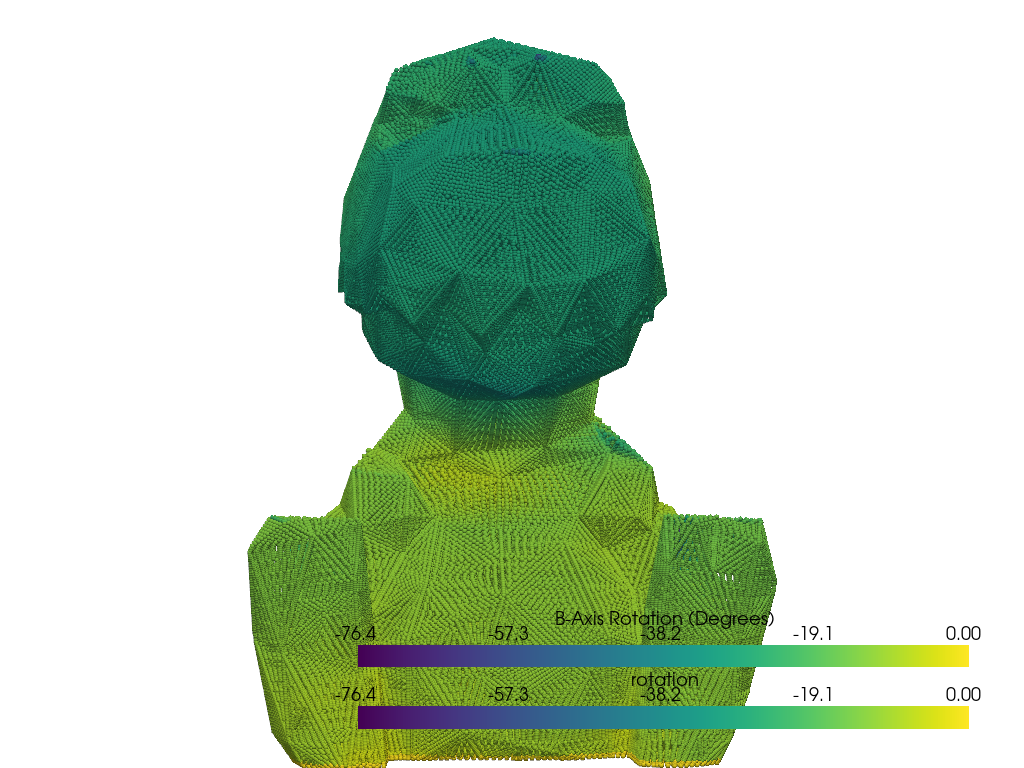

In [50]:
# plot new_gcode_points using pyvista
temp_points = np.array([point["position"] for point in new_gcode_points])
temp = pv.PolyData(temp_points)

# Map available data to cell_data
temp.point_data["rotation"] = np.array([np.rad2deg(point["rotation"]) for point in new_gcode_points])
temp.point_data["z_height"] = temp_points[:, 2]

# Filter for printing moves (G01)
printing_mask = np.array([str(point["command"]) == "G01" for point in new_gcode_points])
printing_moves = temp.extract_points(printing_mask)

# Create a plotter to verify the first layer
plotter = pv.Plotter()
# Fixed: removed 'title' argument from add_mesh
plotter.add_mesh(printing_moves, scalars="rotation", cmap="viridis", point_size=5, render_points_as_spheres=True)
plotter.add_scalar_bar(title="B-Axis Rotation (Degrees)")

# Zoom into the first few layers to verify tilt is zero
plotter.camera_position = 'xz'
plotter.camera.zoom(1.5)

print("Verifying first layer rotation values...")
first_layer_mask = (temp.point_data["z_height"] < 0.5) & printing_mask
if np.any(first_layer_mask):
    max_first_layer_rot = np.max(np.abs(temp.point_data["rotation"][first_layer_mask]))
    print(f"Maximum rotation found in first 0.5mm: {max_first_layer_rot:.4f} degrees")

plotter.show()

In [51]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Filter points to only show printing moves for the slider
printing_pts = [p for p in new_gcode_points if p['command'] == 'G01']
num_pts = len(printing_pts)

def plot_at_step(step_idx):
    # Extract points up to the current step
    current_pts = printing_pts[:step_idx]
    if not current_pts:
        print("No points to display yet.")
        return

    coords = np.array([p['position'] for p in current_pts])
    rots = np.array([np.rad2deg(p['rotation']) for p in current_pts])

    # Create polydata for the current progress
    progress_poly = pv.PolyData(coords)
    progress_poly.point_data['Tilt'] = rots

    plotter = pv.Plotter(window_size=[800, 600])
    plotter.add_mesh(progress_poly, scalars='Tilt', cmap='magma', point_size=4, render_points_as_spheres=True, clim=[np.min(rots), np.max(rots)] if len(rots)>1 else [0,1])
    plotter.add_scalar_bar(title='B-Axis Tilt (deg)')
    plotter.view_isometric()
    plotter.add_text(f"Step: {step_idx} / {num_pts}\nHeight: {coords[-1, 2]:.2f} mm", font_size=10)
    plotter.show()

# Create the interactive slider
step_slider = widgets.IntSlider(
    value=int(num_pts * 0.1),
    min=1,
    max=num_pts,
    step=max(1, num_pts // 100),
    description='Print Progress:',
    layout=widgets.Layout(width='80%')
)

widgets.interact(plot_at_step, step_idx=step_slider)

interactive(children=(IntSlider(value=37368, description='Print Progress:', layout=Layout(width='80%'), max=37…

<function __main__.plot_at_step(step_idx)>

In [52]:
# Inspect specific step 18681
target_idx = 18681
if target_idx < len(printing_pts):
    p = printing_pts[target_idx]
    print(f"--- Data at Step {target_idx} ---")
    print(f"Position: {p['position']}")
    print(f"Rotation (Deg): {np.rad2deg(p['rotation']):.4f}")
    print(f"Command: {p['command']}")
    print(f"Is Travelling: {p['travelling']}")
else:
    print(f"Index {target_idx} is out of range. Max index is {len(printing_pts)-1}")

--- Data at Step 18681 ---
Position: [ 11.70316102 -21.3585231    0.42925068]
Rotation (Deg): 0.0000
Command: G01
Is Travelling: False


In [53]:
# Interactive plot with increment buttons
output = widgets.Output()

def update_plot(step_idx):
    with output:
        clear_output(wait=True)
        plot_at_step(step_idx)

def on_next_clicked(b):
    if step_slider.value < step_slider.max:
        step_slider.value += 1

def on_prev_clicked(b):
    if step_slider.value > step_slider.min:
        step_slider.value -= 1

btn_next = widgets.Button(description="Next Step (+1)", button_style='info')
btn_prev = widgets.Button(description="Prev Step (-1)", button_style='info')

btn_next.on_click(on_next_clicked)
btn_prev.on_click(on_prev_clicked)

# Reuse the slider from the previous cell or create a new one linked to the same logic
controls = widgets.HBox([btn_prev, btn_next])
display(step_slider, controls, output)

# Observe slider changes to update the plot
def handle_slider_change(change):
    update_plot(change['new'])

step_slider.observe(handle_slider_change, names='value')
# Initial plot
update_plot(step_slider.value)

IntSlider(value=18681, description='Print Progress:', layout=Layout(width='80%'), max=373686, min=1, step=3736…

Output()

In [54]:
# Check data around step 11209 to see why tilt starts
steps_to_check = [11208, 11209, 11210]
print(f"Checking B-axis suppression threshold: {MIN_Z_FOR_TILT}mm\n")

for idx in steps_to_check:
    if idx < len(printing_pts):
        p = printing_pts[idx]
        z_height = p['position'][2]
        rot_deg = np.rad2deg(p['rotation'])
        status = "SUPPRESSED" if z_height < MIN_Z_FOR_TILT else "ACTIVE"
        print(f"Step {idx}: Z={z_height:.4f}mm, Tilt={rot_deg:.4f}° -> Tilt Logic: {status}")

Checking B-axis suppression threshold: 0.5mm

Step 11208: Z=0.3490mm, Tilt=0.0000° -> Tilt Logic: SUPPRESSED
Step 11209: Z=0.3488mm, Tilt=0.0000° -> Tilt Logic: SUPPRESSED
Step 11210: Z=0.3486mm, Tilt=0.0000° -> Tilt Logic: SUPPRESSED


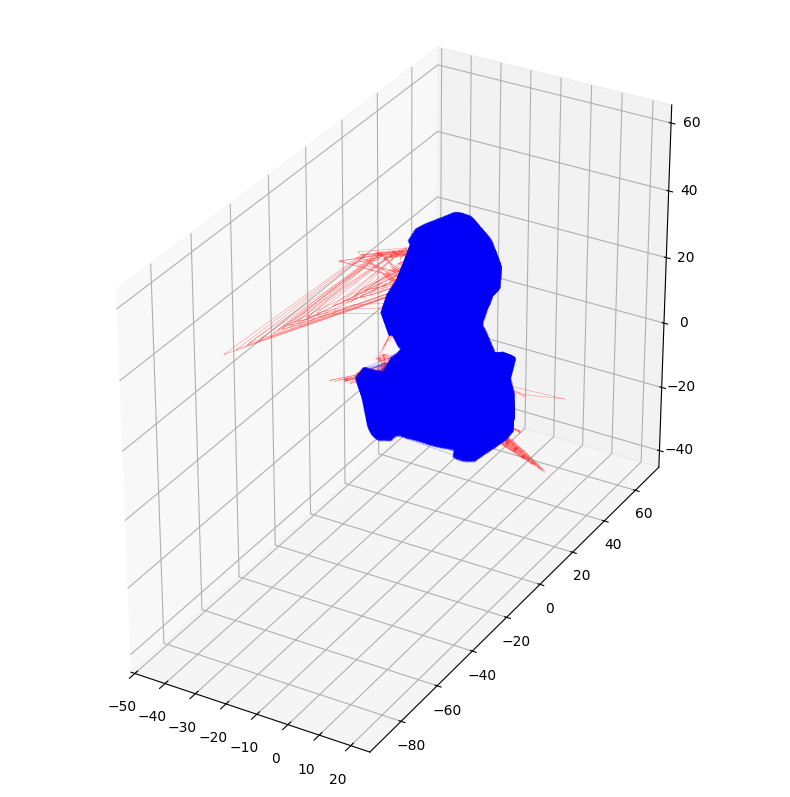

In [47]:
import matplotlib.pyplot as plt
%matplotlib inline

# plot the gcode
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
cmap = plt.get_cmap('viridis')

# Assign 'command' to point_data as well, for plotting
temp.point_data["command"] = np.array([str(point["command"]) for point in new_gcode_points])

# Use point_data for rotation and command
rotation_normalized = temp.point_data["rotation"] / np.max(np.abs(temp.point_data["rotation"]),axis=0)
colors = cmap(rotation_normalized)
# for i in np.arange(len(temp.points)-1):
#     ax.plot(
#         [temp.points[i,0],temp.points[i+1,0]],
#         [temp.points[i,1],temp.points[i+1,1]],
#         [temp.points[i,2],temp.points[i+1,2]],
#         c=colors[i],
#         markersize=0.8, linewidth=0.9, marker='.', alpha=0.5)
# plot G00 moves in different color
g00_indices = np.where(temp.point_data["command"] == "G00")[0]
g01_indices = np.where(temp.point_data["command"] == "G01")[0]
ax.plot(temp.points[g00_indices,0], temp.points[g00_indices,1], temp.points[g00_indices,2], markersize=0.4, linewidth=0.3, marker=".", alpha=0.5, color="red")
ax.plot(temp.points[g01_indices,0], temp.points[g01_indices,1], temp.points[g01_indices,2], markersize=0.4, linewidth=0.3, marker=".", alpha=0.5, color="blue")
ax.set_box_aspect((np.ptp(temp.points[:,0]), np.ptp(temp.points[:,1]), np.ptp(temp.points[:,2])))
plt.show()